In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
df = pd.read_csv('combined_marine_dataset_3sites.csv')
df.head()

,STATION_ID,MMP_SITE_NAME,LONGITUDE,LATITUDE,LOGGER_SERIAL,SAMPLE_DAY,CHL_QA_AVG,NTU_QA_AVG
0,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-22,1.910,3.901
1,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-23,1.935,3.958
2,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-24,1.867,2.408
3,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-25,2.166,1.352
4,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-26,1.911,1.058


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7740 entries, 0 to 7739
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STATION_ID     7740 non-null   object 
 1   MMP_SITE_NAME  7740 non-null   object 
 2   LONGITUDE      7740 non-null   float64
 3   LATITUDE       7740 non-null   float64
 4   LOGGER_SERIAL  7740 non-null   int64  
 5   SAMPLE_DAY     7740 non-null   object 
 6   CHL_QA_AVG     7740 non-null   float64
 7   NTU_QA_AVG     7698 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 483.9+ KB


,LONGITUDE,LATITUDE,LOGGER_SERIAL,CHL_QA_AVG,NTU_QA_AVG
count,7740.000000,7740.000000,7740.000000,7740.000000,7698.000000
mean,147.558558,-19.088668,1619.566279,0.718076,4.157204
std,1.128009,1.404767,1856.183717,0.396654,6.671013
min,145.996300,-20.377900,351.000000,0.035000,0.274000
25%,145.996300,-20.377900,822.000000,0.436000,0.999000
50%,147.582200,-19.587500,842.000000,0.702000,2.022000
75%,148.888400,-16.923200,1329.000000,0.941000,4.757000
max,148.888400,-16.923200,7380.000000,7.965000,117.268000


In [4]:
df["SAMPLE_DAY"] = pd.to_datetime(df["SAMPLE_DAY"])
df["SAMPLE_DAY"].head()

0   2015-03-22
1   2015-03-23
2   2015-03-24
3   2015-03-25
4   2015-03-26
Name: SAMPLE_DAY, dtype: datetime64[ns]

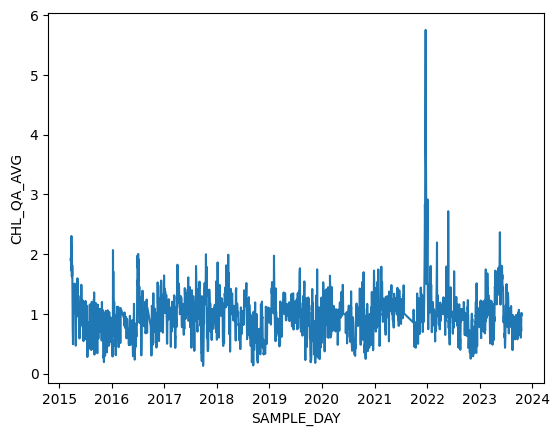

In [5]:
plt.figure()

df_bur13 = df[df["STATION_ID"] == "BUR13"]

# set the index to the "SAMPLE_DAY" column
df_bur13.set_index("SAMPLE_DAY", inplace=True)

# create the chlorophyll plot
ax_bur13_chl = sns.lineplot(data=df_bur13, x="SAMPLE_DAY", y="CHL_QA_AVG")

plt.show()

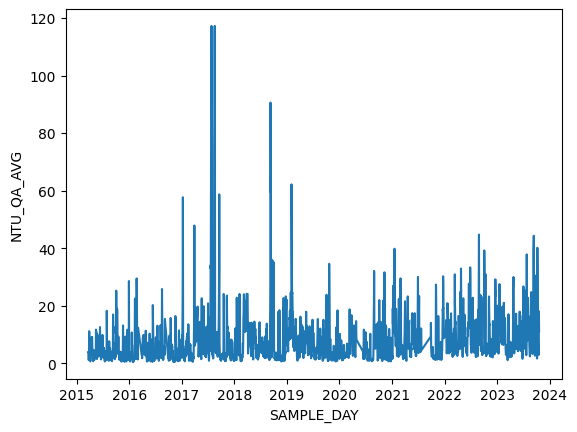

In [6]:
plt.figure()

ax_bur13_ntu = sns.lineplot(data=df_bur13, x="SAMPLE_DAY", y="NTU_QA_AVG")
plt.show()

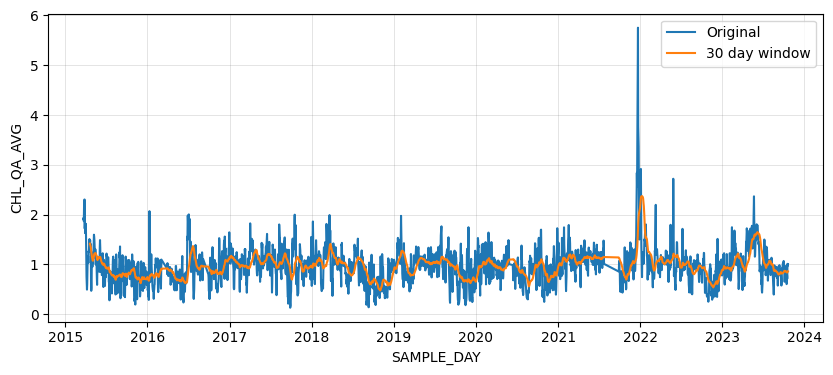

In [7]:
plt.figure(figsize=(10, 4))


# plot the original chlorophyll data
ax_moving_average = sns.lineplot(df_bur13, x="SAMPLE_DAY", y="CHL_QA_AVG", label="Original")

# find the moving average for a window of length 30
bur13_moving_average = df_bur13["CHL_QA_AVG"].rolling(window=30).mean()

# plot the moving average 
sns.lineplot(bur13_moving_average, label="30 day window", ax=ax_moving_average)

# Add the grid
ax_moving_average.grid(color="gray", linestyle="-", linewidth=0.5, alpha=0.3)


plt.legend()

plt.show()

In [8]:
chl_pct_change = df_bur13["NTU_QA_AVG"].pct_change(fill_method=None) * 100
max_pct_change_value = chl_pct_change.abs().max()
max_pct_change_date = chl_pct_change[chl_pct_change.abs() == max_pct_change_value].index
print("The maximum percent change value happened on",max_pct_change_date[0],
      "with a value of", round(max_pct_change_value,2), "%")

The maximum percent change value happened on 2019-12-18 00:00:00 with a value of 1430.64 %


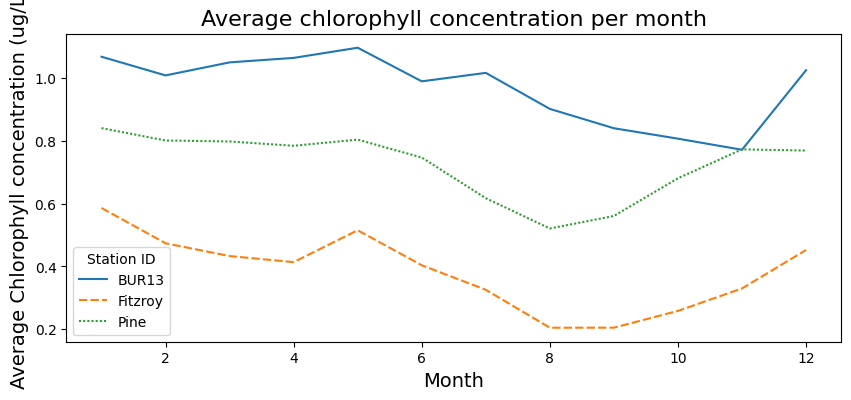

In [9]:
df["MONTH"] = df["SAMPLE_DAY"].dt.month

pivoted_df = df.pivot_table(index="MONTH",
                      columns="STATION_ID",
                      values="CHL_QA_AVG",
                      aggfunc="mean"
                      ) 

plt.figure(figsize=(10, 4))

ax_monthly_chl = sns.lineplot(data=pivoted_df)

# set the x label
plt.xlabel("Month", fontsize=14)

# set the ylabel
plt.ylabel("Average Chlorophyll concentration (ug/L)", fontsize=14)

# change the legend title
plt.legend(title="Station ID")

# set the rotation for the xticks
plt.xticks(rotation=0, fontsize=10)

# set the title
plt.title("Average chlorophyll concentration per month", fontsize=16)


plt.show()

In [10]:
df_bur13_chl = df_bur13[["CHL_QA_AVG"]]

df_bur13_chl["idx"] = range(0, len(df_bur13_chl))
predictors_simple = ["idx"]

X_simple = sm.add_constant(df_bur13_chl["idx"])

Y = df_bur13_chl["CHL_QA_AVG"]

model_simple = sm.OLS(Y, X_simple)

results_simple = model_simple.fit()
print(results_simple.summary())

                            OLS Regression Results                            
Dep. Variable:             CHL_QA_AVG   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     31.48
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.20e-08
Time:                        22:56:35   Log-Likelihood:                -1247.6
No. Observations:                3009   AIC:                             2499.
Df Residuals:                    3007   BIC:                             2511.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9075      0.013     67.949      0.0

/tmp/ipykernel_31787/614323129.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bur13_chl["idx"] = range(0, len(df_bur13_chl))


const    0.907541
idx      0.000043
dtype: float64


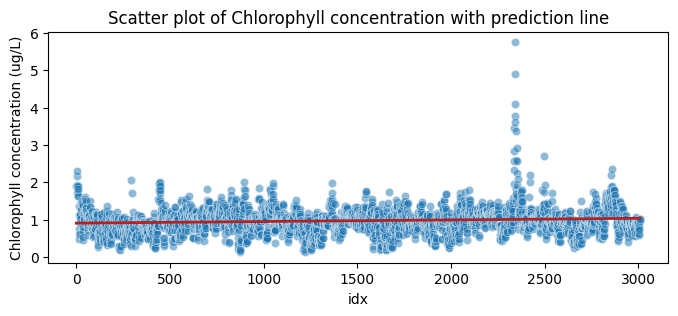

In [11]:
params = results_simple.params
print(results_simple.params)
a = params.iloc[1]
b = params.iloc[0]

# define the prediction line
line = a * df_bur13_chl["idx"] + b

# create a scarper plot with the independent vs. dependent variable
plt.figure(figsize=(8,3))
sns.scatterplot(x=df_bur13_chl["idx"], y=df_bur13_chl["CHL_QA_AVG"], alpha=0.5)

sns.lineplot(x=df_bur13_chl["idx"], y=line, color="firebrick", linewidth=2)

plt.ylabel("Chlorophyll concentration (ug/L)")
plt.title("Scatter plot of Chlorophyll concentration with prediction line")
plt.show()

In [12]:
# add a MONTH column
df_bur13_chl["MONTH"] = df_bur13.index.month


# define the predictors
predictors_multi = ["idx", "MONTH"]

# define X_multi - remember to create a constant column
X_multi = sm.add_constant(df_bur13_chl[predictors_multi])

# define the model. Use the same target Y as before
model_multi = sm.OLS(Y, X_multi)

# train the model
results_multi = model_multi.fit()

/tmp/ipykernel_31787/1131439142.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bur13_chl["MONTH"] = df_bur13.index.month


In [13]:
y_pred = results_multi.predict(X_multi)
residuals = Y - y_pred
MAE = (1/len(residuals)) * residuals.abs().sum()

print("MAE:", round(MAE,4)) 

MAE: 0.2497


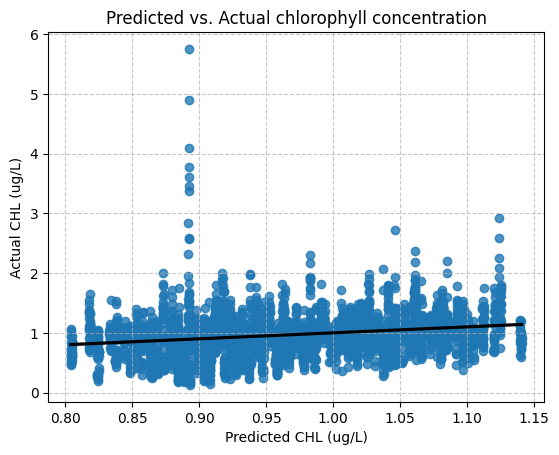

In [14]:
regplot = sns.regplot(x=y_pred, y=Y, line_kws={'color': 'black'})

plt.xlabel("Predicted CHL (ug/L)")
plt.ylabel("Actual CHL (ug/L)")

plt.title("Predicted vs. Actual chlorophyll concentration")

plt.grid(alpha=0.7, linestyle="--")

plt.show()
